# Customer Clustering and Transaction Behavior Profiling

This notebook builds the customer clustering model and the historical transaction behavior profile associated with each cluster.

The workflow is explicitly separated into two stages:

1. **Customer clustering** uses customer and product-derived attributes only.
2. **Transaction behavior profiling** starts after the cluster assignment and describes the expected behavior of each cluster.

Transaction behavior is **not** used as an input to KMeans.

Two independent artifacts are persisted:

- `customer_cluster_model.joblib`: fitted customer preprocessor, PCA, KMeans, and metadata.
- `cluster_behavior_profiles.joblib`: historical transaction behavior statistics for each cluster.

## Project setup

The notebook assumes the following project structure:

```text
Hackaton/
├── models/
│   ├── customer_clustering/
│   └── transaction_profiles/
├── notebooks/
└── src/
    ├── config/
    ├── database/
    └── preprocessing/
```

The persisted artifacts can later be loaded by an inference or testing process.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config.config import PathsConfig
from src.database.connections import get_motherduck_connection
from src.database.readers.bank_reader import BankDBReader
from src.preprocessing.pipelines import (
    CustomerPreprocessor,
    TransactionBehaviorPipeline,
)

RANDOM_STATE = 42
N_PCA_COMPONENTS = 6
N_CLUSTERS = 3
K_VALUES = range(2, 11)
BASELINE_MONTHS = 12
RECENT_DAYS = 30

models_dir = project_root / "models"
customer_clustering_dir = models_dir / "customer_clustering"
transaction_profiles_dir = models_dir / "transaction_profiles"

customer_clustering_dir.mkdir(parents=True, exist_ok=True)
transaction_profiles_dir.mkdir(parents=True, exist_ok=True)

CUSTOMER_MODEL_PATH = customer_clustering_dir / "customer_cluster_model.joblib"
TRANSACTION_PROFILE_PATH = transaction_profiles_dir / "cluster_behavior_profiles.joblib"

print(f"Project root: {project_root}")
print(f"Customer model: {CUSTOMER_MODEL_PATH}")
print(f"Transaction profiles: {TRANSACTION_PROFILE_PATH}")

Project root: C:\Users\Administrador\Desktop\Hackaton
Customer model: C:\Users\Administrador\Desktop\Hackaton\models\customer_clustering\customer_cluster_model.joblib
Transaction profiles: C:\Users\Administrador\Desktop\Hackaton\models\transaction_profiles\cluster_behavior_profiles.joblib


# Stage 1 — Customer clustering

The first stage creates customer groups from customer and product information.

`segment` is intentionally excluded from the clustering inputs because it is used later for external interpretation and validation.

## 1. Load the cleaned customer dataset

In [2]:
cleaned_data_path = PathsConfig.CLEAN_DATA_PATH
customers_df = pd.read_csv(cleaned_data_path)

print(f"Rows: {len(customers_df):,}")
print(f"Unique customers: {customers_df['customer_id'].nunique():,}")

customers_df.head()

Rows: 72,380
Unique customers: 72,380


,customer_id,date_of_birth,country,segment,credit_score,income_usd,occupation,education_level,customer_status,Cuenta Ahorro,...,Inversión,Préstamo Hipotecario,Préstamo Personal,Seguro,Tarjeta Crédito,Tarjeta Débito,num_products,Deuda_usd,Activos_financieros_usd,Edad
0,CLI-G4X2AMVD62NR,1967-06-18,Colombia,Plus,701.0,7329.494286,Administrative,University,Active,0.00,...,0.00,0.0,0.0,0.0,1789.106999,0.0,2,1789.106999,4806.458992,59
1,CLI-8WU28O74XKHS,1995-02-09,México,Basic,657.0,1567.247000,Teacher,NaN,Active,6702.06,...,0.00,0.0,0.0,0.0,1058.870000,0.0,2,1058.870000,6702.060000,31
2,CLI-C4Z5FPK4YO51,1985-07-22,México,Basic,594.0,1389.186150,Lawyer,Elementary,Active,500.61,...,1948.10,0.0,0.0,0.0,2345.510000,0.0,4,2345.510000,5508.660000,41
3,CLI-5OWUVS7SPGKX,1944-04-11,México,Basic,604.0,793.675300,Lawyer,College Prep,Active,11157.03,...,0.00,0.0,0.0,0.0,4859.160000,0.0,3,4859.160000,13624.670000,82
4,CLI-WUJQSWH9HDOS,1992-05-23,México,Plus,726.0,8645.649100,Retired,Graduate,Active,3866.15,...,20454.85,0.0,0.0,0.0,5196.390000,0.0,4,5196.390000,26365.820000,34


## 2. Define customer clustering features

Financial variables are highly right-skewed, so the selected financial variables are transformed with `log1p` and then standardized.

Categorical variables are one-hot encoded.

In [3]:
numerical_columns = ["Edad"]

log_columns = [
    "credit_score",
    "income_usd",
    "Deuda_usd",
    "Activos_financieros_usd",
]

categorical_columns = [
    "country",
    "education_level",
]

required_customer_columns = [
    "customer_id",
    *numerical_columns,
    *log_columns,
    *categorical_columns,
]

missing_columns = [
    column
    for column in required_customer_columns
    if column not in customers_df.columns
]

if missing_columns:
    raise KeyError(f"Missing customer columns: {missing_columns}")

## 3. Fit the customer preprocessor

The fitted preprocessor becomes part of the persisted clustering artifact. This guarantees that future customers are transformed exactly as the training data were transformed.

In [4]:
preprocessor = CustomerPreprocessor(
    log_columns=log_columns,
    numerical_columns=numerical_columns,
    categorical_columns=categorical_columns,
)

X = preprocessor.fit_transform(customers_df)
feature_names = preprocessor.get_feature_names()

print(f"Transformed matrix shape: {X.shape}")
for index, feature_name in enumerate(feature_names):
    print(index, feature_name)

Transformed matrix shape: (72380, 14)
0 log_numeric__credit_score
1 log_numeric__income_usd
2 log_numeric__Deuda_usd
3 log_numeric__Activos_financieros_usd
4 numeric__Edad
5 categorical__country_Argentina
6 categorical__country_Colombia
7 categorical__country_México
8 categorical__education_level_College Prep
9 categorical__education_level_Elementary
10 categorical__education_level_Graduate
11 categorical__education_level_High School
12 categorical__education_level_University
13 categorical__education_level_nan


## 4. Fit PCA

Six principal components are retained based on the previous PCA analysis, where they explained approximately 84.7% of total variance.

In [5]:
pca = PCA(n_components=N_PCA_COMPONENTS)
X_pca = pca.fit_transform(X)

explained_variance_df = pd.DataFrame({
    "Component": [f"PC{i + 1}" for i in range(N_PCA_COMPONENTS)],
    "ExplainedVariance": pca.explained_variance_ratio_,
    "CumulativeVariance": np.cumsum(pca.explained_variance_ratio_),
})

explained_variance_df

,Component,ExplainedVariance,CumulativeVariance
0,PC1,0.263441,0.263441
1,PC2,0.194410,0.457850
2,PC3,0.155691,0.613541
3,PC4,0.117563,0.731105
4,PC5,0.067848,0.798953
5,PC6,0.047957,0.846910


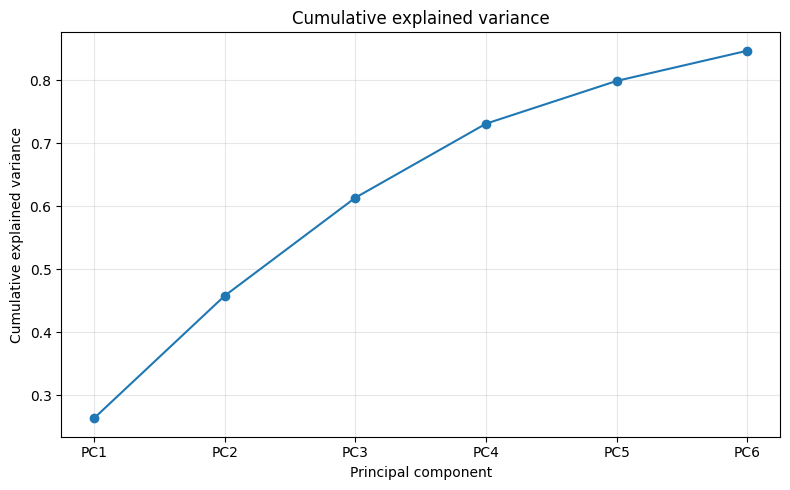

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(
    explained_variance_df["Component"],
    explained_variance_df["CumulativeVariance"],
    marker="o",
)
plt.xlabel("Principal component")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Analyze PCA feature contributions

Feature contributions are computed from squared PCA loadings. The sign of a principal component is arbitrary, so interpretation should focus on relative magnitude.

In [7]:
loadings = pca.components_.T

contributions = (
    loadings ** 2
    / np.sum(loadings ** 2, axis=0)
) * 100

contributions_df = pd.DataFrame(
    contributions,
    index=feature_names,
    columns=[f"PC{i + 1}" for i in range(N_PCA_COMPONENTS)],
)

contributions_df

,PC1,PC2,PC3,PC4,PC5,PC6
log_numeric__credit_score,49.120804,0.003317,2.246660e-02,2.762837e-01,20.062382,18.959492
log_numeric__income_usd,50.268384,0.000461,4.620980e-03,4.560338e-02,13.685950,19.304731
log_numeric__Deuda_usd,0.009912,49.856637,2.072578e-02,4.977880e+01,0.281656,0.027867
log_numeric__Activos_financieros_usd,0.014838,50.088958,6.612042e-03,4.924016e+01,0.529535,0.045036
numeric__Edad,0.022924,0.025729,9.994178e+01,1.274228e-03,0.006408,0.000017
categorical__country_Argentina,0.240664,0.011715,3.886324e-06,2.869499e-01,7.533059,10.841526
categorical__country_Colombia,0.005067,0.000017,1.101740e-03,4.756635e-03,14.666215,41.083712
categorical__country_México,0.315572,0.012631,1.236496e-03,3.655960e-01,43.221305,9.715754
categorical__education_level_College Prep,0.001445,0.000011,4.587254e-07,3.030805e-06,0.009044,0.001081
categorical__education_level_Elementary,0.000149,0.000150,4.219749e-05,2.369000e-04,0.001178,0.003296


## 6. Build the PCA dataset

A separate dataframe is used so that the original cleaned customer dataframe remains unchanged.

In [8]:
pca_columns = [f"pca_{i}" for i in range(1, N_PCA_COMPONENTS + 1)]

customer_pca_df = customers_df.copy()
for index, column_name in enumerate(pca_columns):
    customer_pca_df[column_name] = X_pca[:, index]

X_cluster = customer_pca_df[pca_columns]

print(f"Clustering matrix shape: {X_cluster.shape}")
X_cluster.head()

Clustering matrix shape: (72380, 6)


,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6
0,1.146602,0.198479,0.379630,-0.536175,0.467888,0.635012
1,-0.412965,0.065713,-1.182482,-0.460729,-0.923631,0.149806
2,-1.118814,0.231277,-0.641960,-0.585388,-0.581606,-0.167506
3,-1.450510,0.100270,1.617252,-0.897350,-0.860197,0.148204
4,1.447732,-0.000247,-0.992348,-1.045543,-0.712551,-0.230382


## 7. Evaluate candidate values of K

Inertia measures within-cluster compactness. The silhouette score measures cohesion and separation.

In [9]:
inertias = []
silhouette_scores = []

for k in K_VALUES:
    candidate_kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = candidate_kmeans.fit_predict(X_cluster)
    inertias.append(candidate_kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

clustering_evaluation = pd.DataFrame({
    "K": list(K_VALUES),
    "Inertia": inertias,
    "Silhouette": silhouette_scores,
})

clustering_evaluation

,K,Inertia,Silhouette
0,2,300514.041223,0.242453
1,3,240590.539729,0.279650
2,4,198311.763956,0.263299
3,5,177991.995790,0.239102
4,6,159495.685454,0.249967
5,7,145413.958348,0.249596
6,8,134976.890759,0.253045
7,9,126356.022506,0.251900
8,10,120096.015366,0.252690


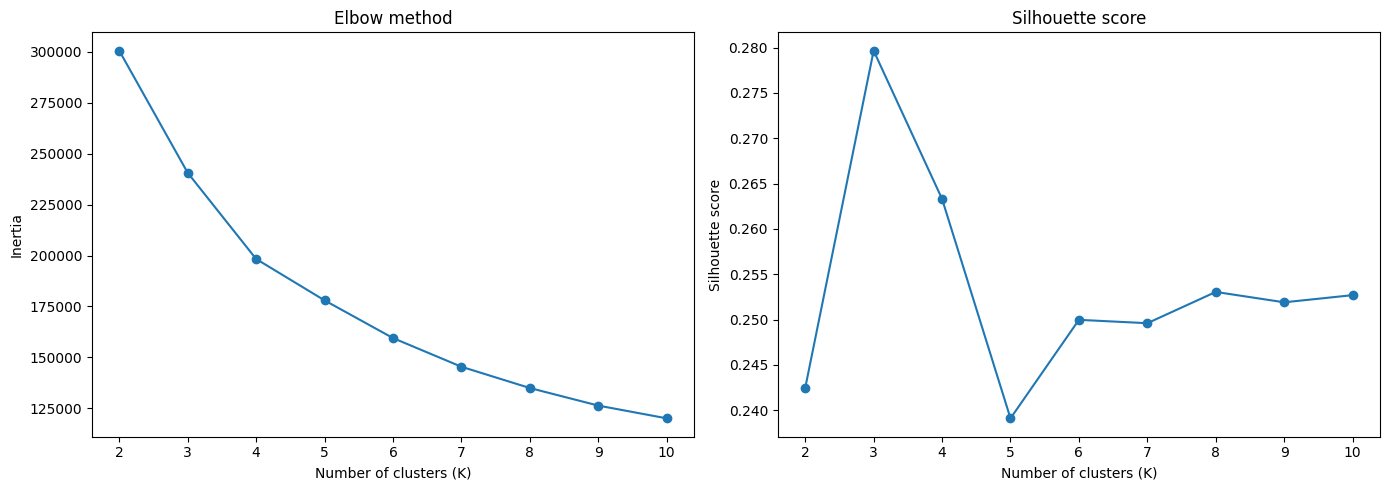

,K,Inertia,Silhouette
1,3,240590.539729,0.279650
2,4,198311.763956,0.263299
6,8,134976.890759,0.253045
8,10,120096.015366,0.252690
7,9,126356.022506,0.251900
4,6,159495.685454,0.249967
5,7,145413.958348,0.249596
0,2,300514.041223,0.242453
3,5,177991.995790,0.239102


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    clustering_evaluation["K"],
    clustering_evaluation["Inertia"],
    marker="o",
)
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(
    clustering_evaluation["K"],
    clustering_evaluation["Silhouette"],
    marker="o",
)
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score")

plt.tight_layout()
plt.show()

clustering_evaluation.sort_values("Silhouette", ascending=False)

## 8. Fit the final KMeans model

The final solution uses **K = 3**, based on the previous evaluation and the interpretability of the resulting customer groups.

In [11]:
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
)

customer_pca_df["cluster"] = kmeans.fit_predict(X_cluster)

cluster_distribution = (
    customer_pca_df
    .groupby("cluster")
    .agg(customers=("customer_id", "nunique"))
    .reset_index()
)

cluster_distribution["percentage"] = (
    cluster_distribution["customers"]
    / cluster_distribution["customers"].sum()
    * 100
)

cluster_distribution

,cluster,customers,percentage
0,0,8205,11.336004
1,1,42617,58.879525
2,2,21558,29.784471


## 9. Interpret the customer clusters

The original variables are used only after fitting KMeans. `segment` is an external interpretation variable and is not used in model training.

In [12]:
cluster_numeric_profile = (
    customer_pca_df
    .groupby("cluster")
    .agg(
        customers=("customer_id", "nunique"),
        mean_age=("Edad", "mean"),
        median_age=("Edad", "median"),
        mean_credit_score=("credit_score", "mean"),
        median_credit_score=("credit_score", "median"),
        mean_income_usd=("income_usd", "mean"),
        median_income_usd=("income_usd", "median"),
        mean_debt_usd=("Deuda_usd", "mean"),
        median_debt_usd=("Deuda_usd", "median"),
        mean_assets_usd=("Activos_financieros_usd", "mean"),
        median_assets_usd=("Activos_financieros_usd", "median"),
    )
)

cluster_numeric_profile

,customers,mean_age,median_age,mean_credit_score,median_credit_score,mean_income_usd,median_income_usd,mean_debt_usd,median_debt_usd,mean_assets_usd,median_assets_usd
cluster,,,,,,,,,,,
0,8205,52.298233,52.0,646.838635,632.0,5482.123002,2562.804535,17396.538804,3085.910,0.406216,0.000000
1,42617,52.630758,53.0,603.532745,603.0,2095.959064,1937.526250,10043.034376,1202.290,9483.289322,7446.534710
2,21558,52.303739,52.0,731.844373,723.0,12185.960022,9280.378556,10518.240170,1285.735,9641.417648,7585.684473


In [13]:
segment_profile = pd.crosstab(
    customer_pca_df["cluster"],
    customer_pca_df["segment"],
    normalize="index",
) * 100

segment_profile

segment,Basic,Plus,Premium,Student
cluster,,,,
0,60.219378,24.777575,10.140158,4.862888
1,89.593355,2.895558,0.000000,7.511087
2,1.790519,68.072177,30.100195,0.037109


## 10. Persist the complete customer clustering model

The artifact contains everything required for future cluster assignment.

In [14]:
customer_clustering_bundle = {
    "preprocessor": preprocessor,
    "pca": pca,
    "kmeans": kmeans,
    "feature_config": {
        "log_columns": log_columns,
        "numerical_columns": numerical_columns,
        "categorical_columns": categorical_columns,
    },
    "required_input_columns": required_customer_columns,
    "pca_columns": pca_columns,
    "n_pca_components": N_PCA_COMPONENTS,
    "n_clusters": N_CLUSTERS,
    "random_state": RANDOM_STATE,
}

joblib.dump(customer_clustering_bundle, CUSTOMER_MODEL_PATH)
print(f"Saved customer clustering model to: {CUSTOMER_MODEL_PATH}")

Saved customer clustering model to: C:\Users\Administrador\Desktop\Hackaton\models\customer_clustering\customer_cluster_model.joblib


# Stage 2 — Transaction behavior profiling

Transaction behavior is analyzed **after** cluster assignment.

The historical design is:

```text
12-month baseline                  recent 30 days
<-------------------------------->|<-------------->
       profile construction             test
```

The latest 30 days are excluded from the baseline to avoid leakage.

## 11. Retrieve transaction history

The transaction population corresponds to the customers used by the clustering model. `BankDBReader` is expected to batch customer IDs internally.

In [15]:
customer_ids = (
    customer_pca_df["customer_id"]
    .dropna()
    .unique()
    .tolist()
)

print(f"Customers to retrieve transactions for: {len(customer_ids):,}")

Customers to retrieve transactions for: 72,380


In [16]:
con = get_motherduck_connection("latam_bank")
reader = BankDBReader(con)

transacciones = reader.consulta_transacciones_batches(
    customer_ids=customer_ids,
    batch_size=10_000,
)

con.close()

transacciones["transaction_date"] = pd.to_datetime(
    transacciones["transaction_date"],
    errors="coerce",
)
transacciones = transacciones.dropna(subset=["transaction_date"])

print(f"Transactions loaded: {len(transacciones):,}")
print(f"Min transaction date: {transacciones['transaction_date'].min()}")
print(f"Max transaction date: {transacciones['transaction_date'].max()}")

C:\Users\Administrador\Desktop\Hackaton\src\database\readers\bank_reader.py:251: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(


Procesados 10,000 de 72,380 clientes
Procesados 20,000 de 72,380 clientes
Procesados 30,000 de 72,380 clientes
Procesados 40,000 de 72,380 clientes
Procesados 50,000 de 72,380 clientes
Procesados 60,000 de 72,380 clientes
Procesados 70,000 de 72,380 clientes
Procesados 72,380 de 72,380 clientes
Transactions loaded: 2,314,171
Min transaction date: 2023-06-17 06:01:30
Max transaction date: 2026-06-18 05:59:41


## 12. Define baseline and recent windows

The latest available transaction date is the reference point.

- Baseline: the 12 months immediately before the recent period.
- Recent period: the latest 30 days.

In [17]:
transaction_cutoff = transacciones["transaction_date"].max()

recent_end = transaction_cutoff
recent_start = recent_end - pd.Timedelta(days=RECENT_DAYS - 1)

baseline_end = recent_start - pd.Timedelta(days=1)
baseline_start = (
    baseline_end
    - pd.DateOffset(months=BASELINE_MONTHS)
    + pd.Timedelta(days=1)
)

print(f"Baseline start: {baseline_start}")
print(f"Baseline end:   {baseline_end}")
print(f"Recent start:   {recent_start}")
print(f"Recent end:     {recent_end}")

Baseline start: 2025-05-20 05:59:41
Baseline end:   2026-05-19 05:59:41
Recent start:   2026-05-20 05:59:41
Recent end:     2026-06-18 05:59:41


In [18]:
baseline_transactions = transacciones[
    transacciones["transaction_date"].between(
        baseline_start,
        baseline_end,
    )
].copy()

recent_transactions = transacciones[
    transacciones["transaction_date"].between(
        recent_start,
        recent_end,
    )
].copy()

print(f"Baseline transactions: {len(baseline_transactions):,}")
print(f"Recent transactions:   {len(recent_transactions):,}")

Baseline transactions: 768,733
Recent transactions:   63,581


## 13. Clean transaction monetary values

A missing `amount_usd` is replaced by `amount` only when `currency == "USD"`. A missing conversion for another currency remains missing.

In [19]:
def clean_transaction_amounts(transactions: pd.DataFrame) -> pd.DataFrame:
    transactions = transactions.copy()

    if "amount_usd" not in transactions.columns:
        transactions["amount_usd"] = np.nan

    usd_mask = (
        transactions["amount_usd"].isna()
        & transactions["currency"].eq("USD")
    )

    transactions.loc[usd_mask, "amount_usd"] = (
        transactions.loc[usd_mask, "amount"]
    )

    return transactions

baseline_transactions = clean_transaction_amounts(baseline_transactions)
recent_transactions = clean_transaction_amounts(recent_transactions)

## 14. Aggregate transaction behavior by customer

`TransactionBehaviorPipeline` converts transaction-level observations into one row per customer.

In [34]:
def build_transaction_behavior(transactions: pd.DataFrame) -> pd.DataFrame:
    if transactions.empty:
        return pd.DataFrame(columns=["customer_id"])

    pipeline = TransactionBehaviorPipeline()
    behavior = pipeline.fit_transform(transactions)

    if "customer_id" not in behavior.columns:
        raise KeyError(
            "TransactionBehaviorPipeline must return 'customer_id'."
        )

    if not behavior["customer_id"].is_unique:
        raise ValueError(
            "TransactionBehaviorPipeline must return one row per customer."
        )

    return behavior.copy()

baseline_behavior = build_transaction_behavior(baseline_transactions)
recent_behavior = build_transaction_behavior(recent_transactions)

print("Baseline behavior shape:", baseline_behavior.shape)
print("Recent behavior shape:", recent_behavior.shape)
baseline_behavior

Baseline behavior shape: (69598, 24)
Recent behavior shape: (38695, 24)


,customer_id,num_transacciones,num_dias_activos,num_meses_activos,monto_total_usd,monto_promedio_usd,monto_mediano_usd,monto_maximo_usd,monto_p95_usd,monto_std_usd,...,num_ciudades_transaccion,porcentaje_fin_semana,porcentaje_nocturnas,tasa_aprobacion,porcentaje_amount_usd_faltante,transacciones_promedio_mes,transacciones_promedio_mes_activo,transacciones_por_dia_activo,tipo_transaccion_dominante,participacion_tipo_dominante
0,CLI-0011WR7BFJZ8,5,5,4,6915.29,1383.058000,565.600,3582.80,3266.4240,1404.772608,...,2,0.200000,0.200000,0.800000,0.000000,0.384615,1.250000,1.000000,Deposit,0.400000
1,CLI-001AVI5RHIYA,12,12,8,19740.04,1645.003333,436.815,4884.22,4646.3505,1947.962378,...,3,0.250000,0.416667,0.833333,0.000000,0.923077,1.500000,1.000000,Withdrawal,0.333333
2,CLI-00232W4ZDQPP,11,11,8,10445.32,949.574545,472.750,4149.12,2951.8150,1206.360811,...,1,0.181818,0.272727,1.000000,0.000000,0.846154,1.375000,1.000000,Withdrawal,0.545455
3,CLI-0036Z6W8EVPS,5,4,4,4630.73,926.146000,866.240,1994.22,1808.7400,707.526149,...,1,0.000000,0.600000,0.800000,0.000000,0.384615,1.250000,1.250000,Payment,0.600000
4,CLI-003W6OEE5QV2,6,6,6,1837.33,306.221667,236.650,627.95,591.4975,206.986878,...,2,0.166667,0.333333,1.000000,0.000000,0.461538,1.000000,1.000000,Purchase,0.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69593,CLI-ZZW5M8RNQ9DC,9,9,7,3476.36,386.262222,248.650,1554.90,1162.0920,467.247712,...,1,0.111111,0.222222,1.000000,0.000000,0.692308,1.285714,1.000000,Adjustment,0.333333
69594,CLI-ZZXV72EWG5GD,8,8,6,16898.61,2112.326250,1723.910,5975.85,5069.1225,2085.241627,...,1,0.125000,0.000000,1.000000,0.000000,0.615385,1.333333,1.000000,Withdrawal,0.500000
69595,CLI-ZZYPFRJXKM7Q,2,2,2,843.78,421.890000,421.890,813.60,774.4290,553.961595,...,1,0.000000,0.000000,1.000000,0.000000,0.153846,1.000000,1.000000,Deposit,0.500000
69596,CLI-ZZZD7ZEYEM50,22,21,9,20648.34,983.254286,276.010,8582.63,3996.5900,1950.149316,...,3,0.318182,0.318182,0.954545,0.045455,1.692308,2.444444,1.047619,Purchase,0.545455


## 15. Attach cluster labels to baseline behavior

A left join keeps customers without transactions in the baseline population. They are tracked separately as inactive.

In [21]:
cluster_assignments = customer_pca_df[
    ["customer_id", "cluster"]
].drop_duplicates()

baseline_customer_behavior = cluster_assignments.merge(
    baseline_behavior,
    on="customer_id",
    how="left",
)

if "num_transacciones" not in baseline_customer_behavior.columns:
    raise KeyError(
        "TransactionBehaviorPipeline must produce 'num_transacciones'."
    )

baseline_customer_behavior["has_baseline_activity"] = (
    baseline_customer_behavior["num_transacciones"]
    .fillna(0)
    .gt(0)
)

## 16. Measure transaction activity coverage by cluster

In [22]:
cluster_activity = (
    baseline_customer_behavior
    .groupby("cluster")
    .agg(
        total_customers=("customer_id", "nunique"),
        active_customers=("has_baseline_activity", "sum"),
    )
)

cluster_activity["active_customer_ratio"] = (
    cluster_activity["active_customers"]
    / cluster_activity["total_customers"]
)

cluster_activity

,total_customers,active_customers,active_customer_ratio
cluster,,,
0,8205,7416,0.903839
1,42617,41310,0.969331
2,21558,20872,0.968179


## 17. Put baseline and recent behavior on comparable time scales

The baseline covers 12 months while the recent period covers 30 days. Additive quantities such as transaction counts, total monetary amounts, active days, and diversity counts are therefore converted to a monthly-equivalent scale.

Average amounts, percentages, approval rates, and other scale-independent variables do not require this normalization.

In [23]:
MONTHLY_RATE_FEATURES = [
    "num_transacciones",
    "monto_total_usd",
    "num_dias_activos",
    "num_productos",
    "num_tipos_transaccion",
    "num_monedas",
    "num_paises_transaccion",
    "num_ciudades_transaccion",
]

SCALE_INDEPENDENT_FEATURES = [
    "monto_promedio_usd",
    "monto_mediano_usd",
    "monto_maximo_usd",
    "monto_p95_usd",
    "monto_std_usd",
    "transacciones_por_dia_activo",
    "porcentaje_fin_semana",
    "porcentaje_nocturnas",
    "tasa_aprobacion",
    "participacion_tipo_dominante",
]


def normalize_behavior_period(
    behavior: pd.DataFrame,
    period_days: int,
) -> pd.DataFrame:
    result = behavior.copy()
    monthly_factor = 30.0 / period_days

    for column in MONTHLY_RATE_FEATURES:
        if column in result.columns:
            result[f"{column}_monthly"] = (
                pd.to_numeric(result[column], errors="coerce")
                * monthly_factor
            )

    return result


baseline_period_days = (
    baseline_end - baseline_start
).days + 1

baseline_behavior_scaled = normalize_behavior_period(
    baseline_behavior,
    period_days=baseline_period_days,
)

recent_behavior_scaled = normalize_behavior_period(
    recent_behavior,
    period_days=RECENT_DAYS,
)

## 18. Define behavior features used in the cluster profiles

In [ ]:
profile_features = []

for feature in MONTHLY_RATE_FEATURES:
    normalized_name = f"{feature}_monthly"
    if normalized_name in baseline_behavior_scaled.columns:
        profile_features.append(normalized_name)

for feature in SCALE_INDEPENDENT_FEATURES:
    if feature in baseline_behavior_scaled.columns:
        profile_features.append(feature)



## 19. Build robust transaction profiles for each cluster

For each behavior variable and cluster, the profile stores the mean, median, P25, P75, P95, and MAD (median absolute deviation).

In [ ]:
baseline_scaled_with_clusters = cluster_assignments.merge(
    baseline_behavior_scaled[
        ["customer_id", *profile_features]
    ],
    on="customer_id",
    how="left",
)

baseline_scaled_with_clusters = baseline_scaled_with_clusters.merge(
    baseline_customer_behavior[
        ["customer_id", "has_baseline_activity"]
    ],
    on="customer_id",
    how="left",
    suffixes=("", "_activity"),
)

active_baseline_behavior = baseline_scaled_with_clusters[
    baseline_scaled_with_clusters["has_baseline_activity"]
].copy()

profile_rows = []

for cluster_id, cluster_group in active_baseline_behavior.groupby("cluster"):
    for feature in profile_features:
        values = pd.to_numeric(
            cluster_group[feature],
            errors="coerce",
        ).dropna()

        if values.empty:
            continue

        median_value = values.median()
        mad_value = np.median(np.abs(values - median_value))

        profile_rows.append({
            "cluster": cluster_id,
            "feature": feature,
            "count": len(values),
            "mean": values.mean(),
            "median": median_value,
            "p25": values.quantile(0.25),
            "p75": values.quantile(0.75),
            "p95": values.quantile(0.95),
            "mad": mad_value,
        })

cluster_behavior_statistics = pd.DataFrame(profile_rows)


In [44]:
cluster_behavior_statistics

,cluster,feature,count,mean,median,p25,p75,p95,mad
0,0,num_transacciones_monthly,7416,0.527852,0.493151,0.328767,0.657534,1.150685,0.164384
1,0,monto_total_usd_monthly,7416,333.410037,207.889726,102.100274,393.394110,1111.556301,124.193425
2,0,num_dias_activos_monthly,7416,0.522155,0.452055,0.328767,0.657534,1.150685,0.205479
3,0,num_productos_monthly,7416,0.120184,0.082192,0.082192,0.164384,0.246575,0.000000
4,0,num_tipos_transaccion_monthly,7416,0.195017,0.164384,0.164384,0.246575,0.328767,0.082192
5,0,num_monedas_monthly,7416,0.085295,0.082192,0.082192,0.082192,0.082192,0.000000
6,0,num_paises_transaccion_monthly,7416,0.108326,0.082192,0.082192,0.164384,0.164384,0.000000
7,0,num_ciudades_transaccion_monthly,7416,0.105632,0.082192,0.082192,0.082192,0.164384,0.000000
8,0,monto_promedio_usd,7409,627.240685,430.795000,284.360000,733.881000,1771.673417,181.275000
9,0,monto_mediano_usd,7409,462.251360,339.590000,245.910000,473.290000,1205.524000,106.020000


## 20. Persist the transaction behavior profiles

This artifact answers a different question from KMeans:

> Given a cluster, what transaction behavior should be considered normal for customers in that cluster?

In [35]:
cluster_behavior_profiles = {
    "profile_statistics": cluster_behavior_statistics,
    "cluster_activity": cluster_activity.reset_index(),
    "profile_features": profile_features,
    "baseline_window": {
        "start": baseline_start,
        "end": baseline_end,
        "months": BASELINE_MONTHS,
    },
    "recent_window_days": RECENT_DAYS,
    "monthly_rate_features": [
        f"{feature}_monthly"
        for feature in MONTHLY_RATE_FEATURES
        if f"{feature}_monthly" in profile_features
    ],
}

joblib.dump(
    cluster_behavior_profiles,
    TRANSACTION_PROFILE_PATH,
)

print(f"Saved transaction behavior profiles to: {TRANSACTION_PROFILE_PATH}")

Saved transaction behavior profiles to: C:\Users\Administrador\Desktop\Hackaton\models\transaction_profiles\cluster_behavior_profiles.joblib


# Stage 3 — End-to-end inference test

The inference flow is:

```text
Customer attributes
      ↓
Saved preprocessor
      ↓
Saved PCA
      ↓
KMeans.predict()
      ↓
Assigned cluster
      ↓
Recent 30-day transactions
      ↓
TransactionBehaviorPipeline
      ↓
Stored profile of assigned cluster
      ↓
Behavioral deviation score
```

Transaction behavior is never fed back into KMeans during inference.

## 21. Reload persisted artifacts and verify the customer model

In [45]:
loaded_customer_model = joblib.load(CUSTOMER_MODEL_PATH)
loaded_behavior_profiles = joblib.load(TRANSACTION_PROFILE_PATH)

loaded_preprocessor = loaded_customer_model["preprocessor"]
loaded_pca = loaded_customer_model["pca"]
loaded_kmeans = loaded_customer_model["kmeans"]

test_sample = customers_df.iloc[[0]].copy()

original_prediction = int(
    kmeans.predict(
        pca.transform(
            preprocessor.transform(test_sample)
        )
    )[0]
)

reloaded_prediction = int(
    loaded_kmeans.predict(
        loaded_pca.transform(
            loaded_preprocessor.transform(test_sample)
        )
    )[0]
)

assert original_prediction == reloaded_prediction

print("Persisted model verification passed.")
print(f"Test customer: {test_sample['customer_id'].iloc[0]}")
print(f"Predicted cluster: {reloaded_prediction}")
test_sample

Persisted model verification passed.
Test customer: CLI-G4X2AMVD62NR
Predicted cluster: 2


c:\Users\Administrador\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


,customer_id,date_of_birth,country,segment,credit_score,income_usd,occupation,education_level,customer_status,Cuenta Ahorro,...,Inversión,Préstamo Hipotecario,Préstamo Personal,Seguro,Tarjeta Crédito,Tarjeta Débito,num_products,Deuda_usd,Activos_financieros_usd,Edad
0,CLI-G4X2AMVD62NR,1967-06-18,Colombia,Plus,701.0,7329.494286,Administrative,University,Active,0.0,...,0.0,0.0,0.0,0.0,1789.106999,0.0,2,1789.106999,4806.458992,59


## 22. Define a robust behavior deviation score

The score is a robust distance from the historical cluster distribution. It is **not a fraud probability**.

In [38]:
def robust_deviation_score(
    value: float,
    median: float,
    mad: float,
    p25: float,
    p75: float,
) -> float:
    if pd.isna(value):
        return np.nan

    robust_scale = 1.4826 * mad

    if robust_scale > 0:
        return abs(value - median) / robust_scale

    iqr = p75 - p25
    if iqr > 0:
        return abs(value - median) / (iqr / 1.349)

    return 0.0 if value == median else np.inf


def score_behavior_against_cluster(
    behavior: pd.DataFrame,
    cluster_id: int,
    profile_bundle: dict,
) -> pd.DataFrame:
    if behavior.empty:
        return pd.DataFrame()

    profile_statistics = profile_bundle["profile_statistics"]
    profile_features = profile_bundle["profile_features"]

    if profile_statistics.empty:
        return pd.DataFrame()

    behavior_row = behavior.iloc[0]
    cluster_profile = profile_statistics[
        profile_statistics["cluster"] == cluster_id
    ]

    scores = []

    for feature in profile_features:
        if feature not in behavior_row.index:
            continue

        profile_row = cluster_profile[
            cluster_profile["feature"] == feature
        ]
        if profile_row.empty:
            continue

        profile_row = profile_row.iloc[0]
        value = pd.to_numeric(
            pd.Series([behavior_row[feature]]),
            errors="coerce",
        ).iloc[0]

        deviation = robust_deviation_score(
            value=value,
            median=profile_row["median"],
            mad=profile_row["mad"],
            p25=profile_row["p25"],
            p75=profile_row["p75"],
        )

        scores.append({
            "feature": feature,
            "value": value,
            "cluster_median": profile_row["median"],
            "cluster_p25": profile_row["p25"],
            "cluster_p75": profile_row["p75"],
            "deviation_score": deviation,
        })

    result = pd.DataFrame(scores)
    if not result.empty:
        result["is_unusual"] = result["deviation_score"] >= 3

    return result

## 23. Assign a customer to a cluster using the saved model

In [46]:
test_customer = customers_df.iloc[[0]].copy()
test_customer_id = test_customer["customer_id"].iloc[0]

test_X = loaded_preprocessor.transform(test_customer)
test_X_pca = loaded_pca.transform(test_X)

predicted_cluster = int(loaded_kmeans.predict(test_X_pca)[0])

print(f"Customer: {test_customer_id}")
print(f"Predicted cluster: {predicted_cluster}")
test_customer

Customer: CLI-G4X2AMVD62NR
Predicted cluster: 2


c:\Users\Administrador\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


,customer_id,date_of_birth,country,segment,credit_score,income_usd,occupation,education_level,customer_status,Cuenta Ahorro,...,Inversión,Préstamo Hipotecario,Préstamo Personal,Seguro,Tarjeta Crédito,Tarjeta Débito,num_products,Deuda_usd,Activos_financieros_usd,Edad
0,CLI-G4X2AMVD62NR,1967-06-18,Colombia,Plus,701.0,7329.494286,Administrative,University,Active,0.0,...,0.0,0.0,0.0,0.0,1789.106999,0.0,2,1789.106999,4806.458992,59


## 24. Retrieve the customer's recent transactions

In [84]:
con = get_motherduck_connection("latam_bank")
reader = BankDBReader(con)

test_transactions = reader.consulta_transacciones_batches(
    customer_ids=[test_customer_id],
    batch_size=10000,
)

con.close()

test_transactions["transaction_date"] = pd.to_datetime(
    test_transactions["transaction_date"],
    errors="coerce",
)

test_transactions = test_transactions[
    test_transactions["transaction_date"].between(
        recent_start,
        recent_end,
    )
].copy()

test_transactions = clean_transaction_amounts(test_transactions)
test_recent_behavior = build_transaction_behavior(test_transactions)

test_recent_behavior_scaled = normalize_behavior_period(
    test_recent_behavior,
    period_days=RECENT_DAYS,
)

test_recent_behavior_scaled
test_recent_behavior_scaled["monto_maximo_usd"] = 17000
test_recent_behavior_scaled["monto_promedio_usd"] = 7000

C:\Users\Administrador\Desktop\Hackaton\src\database\readers\bank_reader.py:251: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(


Procesados 1 de 1 clientes


## 25. Compare recent behavior with the assigned cluster profile

In [86]:
behavior_scores = score_behavior_against_cluster(
    behavior=test_recent_behavior_scaled,
    cluster_id=0,
    profile_bundle=loaded_behavior_profiles,
)

behavior_scores

,feature,value,cluster_median,cluster_p25,cluster_p75,deviation_score,is_unusual
0,num_transacciones_monthly,1.00,0.493151,0.328767,0.657534,2.079680,False
1,monto_total_usd_monthly,424.75,207.889726,102.100274,393.394110,1.177762,False
2,num_dias_activos_monthly,1.00,0.452055,0.328767,0.657534,1.798642,False
3,num_productos_monthly,1.00,0.082192,0.082192,0.164384,15.063833,True
4,num_tipos_transaccion_monthly,1.00,0.164384,0.164384,0.246575,6.857323,True
5,num_monedas_monthly,1.00,0.082192,0.082192,0.082192,inf,True
6,num_paises_transaccion_monthly,1.00,0.082192,0.082192,0.164384,15.063833,True
7,num_ciudades_transaccion_monthly,1.00,0.082192,0.082192,0.082192,inf,True
8,monto_promedio_usd,7000.00,430.795000,284.360000,733.881000,24.442797,True
9,monto_mediano_usd,424.75,339.590000,245.910000,473.290000,0.541781,False


## 26. Aggregate the behavioral anomaly signal

The initial overall score is the mean of the available feature-level robust deviations. It should be calibrated later using historical validation data.

`is_fraud` and `fraud_score` are intentionally not used to construct the baseline profiles. They should be reserved for a later validation stage.

In [54]:
if behavior_scores.empty:
    overall_behavioral_anomaly_score = np.nan
else:
    valid_scores = (
        behavior_scores["deviation_score"]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    overall_behavioral_anomaly_score = (
        valid_scores.mean()
        if not valid_scores.empty
        else np.nan
    )

print(
    "Overall behavioral anomaly score:",
    overall_behavioral_anomaly_score,
)

Overall behavioral anomaly score: 3.856585046439004


# Final architecture

```text
                         CUSTOMER MODEL
              ┌────────────────────────────┐
              │ CustomerPreprocessor       │
              │ PCA                        │
              │ KMeans                     │
              └──────────────┬─────────────┘
                             │
                             ▼
                    customer_id + cluster
                             │
                             ▼
                 12-month transaction history
                             │
                             ▼
                  behavior per customer
                             │
                             ▼
                 profile grouped by cluster
                             │
                  ┌──────────┴─────────┐
                  ▼                    ▼
        customer_cluster_model   cluster_behavior_profiles

Inference:

New customer attributes
        │
        ▼
Saved Preprocessor → Saved PCA → Saved KMeans.predict()
        │
        ▼
Assigned cluster
        │
        ▼
Recent 30-day transactions
        │
        ▼
TransactionBehaviorPipeline
        │
        ▼
Stored profile of assigned cluster
        │
        ▼
Behavioral deviation / anomaly score
```

The customer model determines **cluster membership**.

The transaction profile determines **expected behavior for that cluster**.

Fraud labels are reserved for later validation of the anomaly signal.